
# Actividad 08 (Unidad II) — Agrupamiento por Jerarquías (Clustering Jerárquico)

*PRESENTADO POR*

**-Oscar Edy Vilca Quispe**

**-Jose Jhonatan Quispe Cartagena**


Este notebook contiene las tres partes solicitadas:

1. **Clustering jerárquico para texto** — dataset *20 Newsgroups* (scikit-learn).
2. **Clustering jerárquico para segmentación de clientes** — dataset tipo *Mall Customer* (Kaggle) / sintético.
3. **Clustering jerárquico para segmentación de imágenes** — imágenes de `scikit-image` (BSDS500-compatible).



---



In [ ]:
# =========================================================
# 0. CONFIGURACIÓN GENERAL DEL ENTORNO
# =========================================================
# Ejecutar esta celda primero. Instala/asegura las librerías necesarias.

!pip -q install scikit-image 2>/dev/null

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Entorno listo.")


Entorno listo.



## Parte 1 — Clustering jerárquico para texto (20 Newsgroups)

### 1.1 Planteamiento

El dataset **20 Newsgroups** contiene ~18,000 publicaciones de foros de discusión (*newsgroups*) repartidas en 20 categorías temáticas. Para poder:

- visualizar dendrogramas legibles, y
- calcular una matriz de distancias completa (el clustering jerárquico aglomerativo clásico es **O(n²)** en memoria y **O(n² log n)** en tiempo),

se trabaja con un **subconjunto** de 4 categorías temáticamente bien diferenciadas y una muestra de tamaño moderado (n ≈ 400 documentos). Esto es una práctica estándar en la literatura de *text clustering*, ya que el algoritmo aglomerativo puro no escala a decenas de miles de documentos sin técnicas adicionales (p. ej. *mini-batch* o *BIRCH*).

Categorías seleccionadas (con temáticas claramente distintas para poder validar el clustering contra las etiquetas reales):

- `comp.graphics` (computación / gráficos)
- `rec.sport.baseball` (deportes)
- `sci.space` (ciencia / espacio)
- `soc.religion.christian` (religión)

### 1.2 Pipeline

1. Descarga y muestreo del corpus (se remueven encabezados, pies de firma y citas para evitar *leakage* trivial, p. ej. direcciones de correo que delatan la categoría).
2. Vectorización **TF-IDF** (representación bolsa de palabras ponderada).
3. Reducción de dimensionalidad con **TruncatedSVD (LSA)** — necesaria porque (a) la métrica *ward* solo admite distancia euclidiana y funciona mal en espacios de altísima dimensión y extrema dispersión (*curse of dimensionality*), y (b) mejora la señal semántica al capturar co-ocurrencias latentes.
4. Cálculo de la matriz de enlace (*linkage*) con **al menos dos criterios distintos**: `ward`, `average`, `complete` y `single` (se prueban los cuatro para tener una comparación más robusta).
5. Visualización de dendrogramas.
6. Corte del árbol en k = 4 clusters (`fcluster`) y evaluación cuantitativa contra las etiquetas reales (que NO se usan para entrenar, solo para validar).
7. Interpretación cualitativa: términos más representativos de cada cluster.


In [ ]:
# =========================================================
# 1.1 Carga y muestreo del corpus
# =========================================================
from sklearn.datasets import fetch_20newsgroups

categories = ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'soc.religion.christian']

newsgroups = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=RANDOM_STATE
)

print(f"Documentos totales descargados: {len(newsgroups.data)}")
print(f"Categorías: {newsgroups.target_names}")

# Submuestreo por costo computacional del clustering jerárquico (O(n^2))
N_SAMPLES_TEXT = 400
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(newsgroups.data), size=min(N_SAMPLES_TEXT, len(newsgroups.data)), replace=False)

docs = [newsgroups.data[i] for i in idx]
y_true_text = newsgroups.target[idx]
target_names_text = newsgroups.target_names

pd.Series(y_true_text).map(lambda i: target_names_text[i]).value_counts()


Documentos totales descargados: 2373
Categorías: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'soc.religion.christian']


,count
sci.space,103
rec.sport.baseball,103
soc.religion.christian,101
comp.graphics,93


In [ ]:
# =========================================================
# 1.2 Vectorización TF-IDF + reducción de dimensionalidad (LSA)
# =========================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

tfidf = TfidfVectorizer(
    stop_words='english',
    max_df=0.6,
    min_df=3,
    max_features=5000,
    sublinear_tf=True
)
X_tfidf = tfidf.fit_transform(docs)
print("Matriz TF-IDF:", X_tfidf.shape)

N_COMPONENTS = min(100, X_tfidf.shape[1] - 1)  # guarda de seguridad: no puede exceder el n de features
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_tfidf)
X_text_norm = normalize(X_svd)  # normalizar para que la distancia euclidiana en el espacio LSA se aproxime a la distancia coseno

print(f"Varianza explicada acumulada por {N_COMPONENTS} componentes LSA: {svd.explained_variance_ratio_.sum():.2%}")


Matriz TF-IDF: (400, 2292)
Varianza explicada acumulada por 100 componentes LSA: 45.21%


In [ ]:
# =========================================================
# 1.3 Cálculo de linkages: se prueban 4 criterios (>= 2 requeridos)
# =========================================================
linkage_matrices_text = {}

# --- Saneamiento previo: la distancia coseno es NaN entre vectores de norma cero
# (documentos que, tras TF-IDF + SVD, quedaron como vector nulo, p. ej. documentos
# vacíos o cuyas palabras fueron todas filtradas por min_df/max_df/stopwords).
# Se detectan y reemplazan por un vector minúsculo no nulo para evitar el ValueError:
# "The condensed distance matrix must contain only finite values."
normas = np.linalg.norm(X_text_norm, axis=1)
n_vectores_nulos = int((normas == 0).sum())
if n_vectores_nulos > 0:
    print(f"Aviso: {n_vectores_nulos} documento(s) quedaron con vector nulo tras TF-IDF/SVD; "
          f"se les asigna un vector minúsculo no nulo para poder calcular distancia coseno.")
    rng_fix = np.random.RandomState(RANDOM_STATE)
    for i in np.where(normas == 0)[0]:
        X_text_norm[i] = rng_fix.normal(size=X_text_norm.shape[1]) * 1e-6

# Ward exige distancia euclidiana
linkage_matrices_text['ward'] = linkage(X_text_norm, method='ward')

# Average / Complete / Single: se calculan sobre distancia coseno,
# métrica más adecuada para vectores de texto (invariante a la longitud del documento)
cos_dist = pdist(X_text_norm, metric='cosine')

# Saneamiento adicional por si quedara algún NaN/inf residual (p. ej. por precisión numérica)
n_no_finitos = int((~np.isfinite(cos_dist)).sum())
if n_no_finitos > 0:
    print(f"Aviso: se corrigieron {n_no_finitos} valores no finitos en la matriz de distancias coseno.")
    cos_dist = np.nan_to_num(cos_dist, nan=1.0, posinf=1.0, neginf=0.0)

for method in ['average', 'complete', 'single']:
    linkage_matrices_text[method] = linkage(cos_dist, method=method)

print("Linkages calculados:", list(linkage_matrices_text.keys()))

Aviso: 15 documento(s) quedaron con vector nulo tras TF-IDF/SVD; se les asigna un vector minúsculo no nulo para poder calcular distancia coseno.
Linkages calculados: ['ward', 'average', 'complete', 'single']


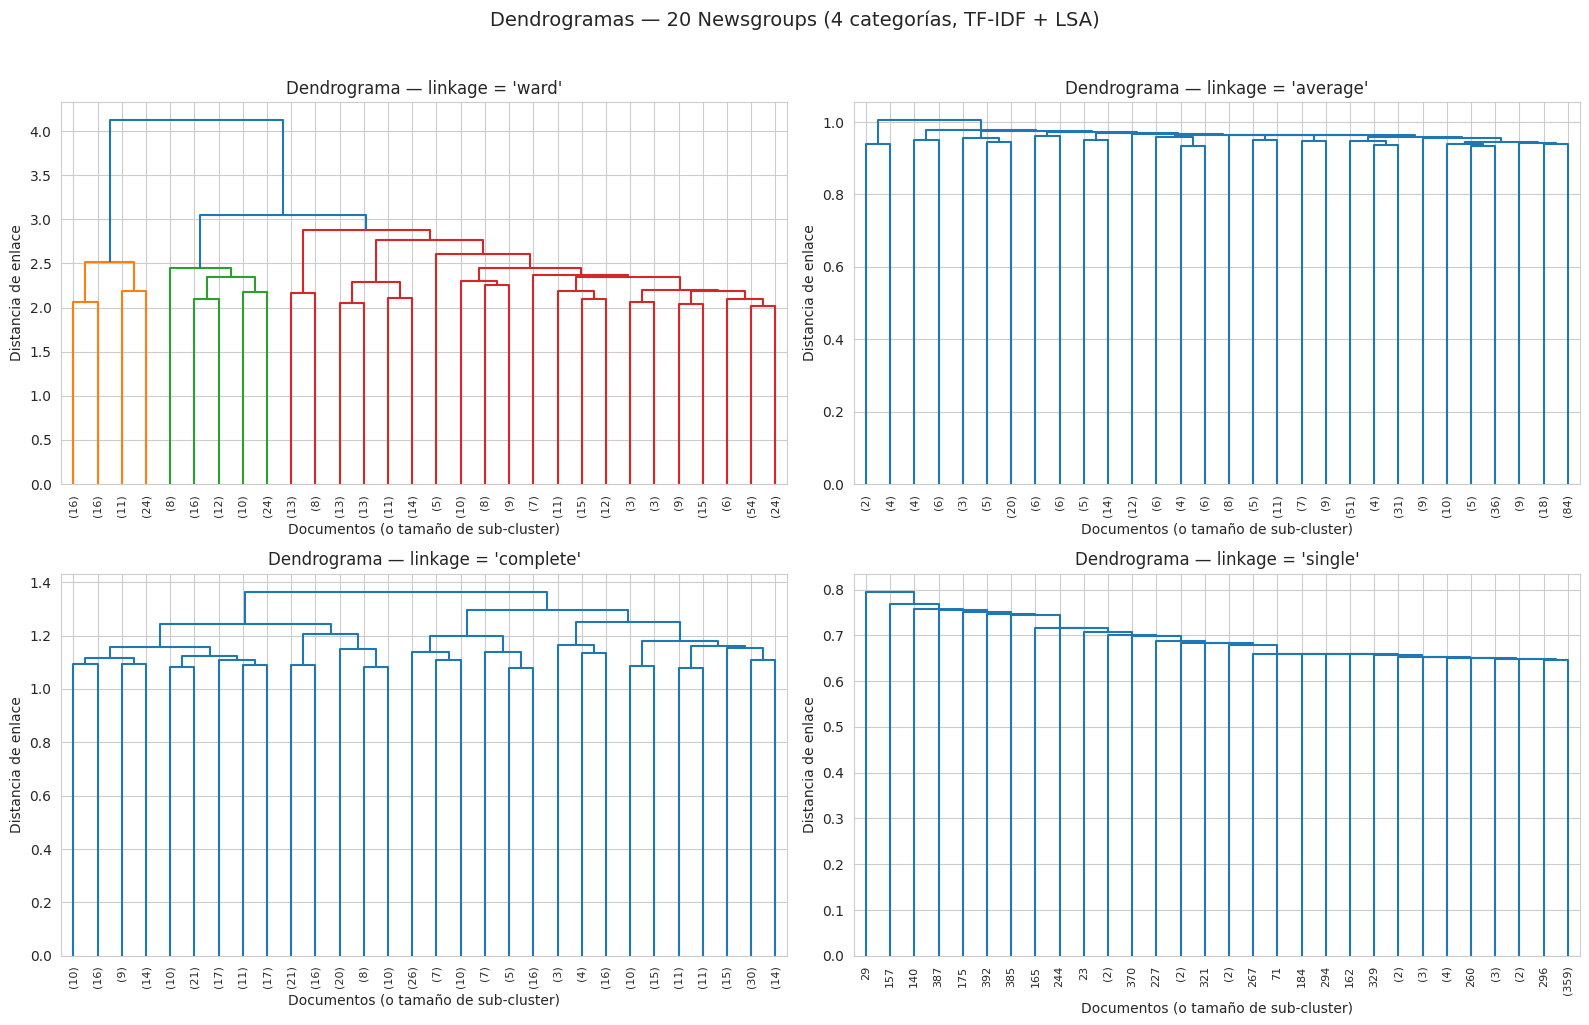

In [ ]:
# =========================================================
# 1.4 Dendrogramas (uno por criterio de linkage)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, (method, Z) in zip(axes, linkage_matrices_text.items()):
    dendrogram(Z, truncate_mode='lastp', p=30, ax=ax,
               show_leaf_counts=True, leaf_rotation=90, leaf_font_size=8)
    ax.set_title(f"Dendrograma — linkage = '{method}'")
    ax.set_xlabel("Documentos (o tamaño de sub-cluster)")
    ax.set_ylabel("Distancia de enlace")

plt.suptitle("Dendrogramas — 20 Newsgroups (4 categorías, TF-IDF + LSA)", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("dendrogramas_texto.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# =========================================================
# 1.5 Corte del árbol y evaluación cuantitativa
# =========================================================
K_TEXT = len(categories)
resultados_texto = []

for method, Z in linkage_matrices_text.items():
    labels_pred = fcluster(Z, t=K_TEXT, criterion='maxclust')
    sil = silhouette_score(X_text_norm, labels_pred, metric='cosine')
    ari = adjusted_rand_score(y_true_text, labels_pred)
    homog = homogeneity_score(y_true_text, labels_pred)
    complet = completeness_score(y_true_text, labels_pred)
    vmeas = v_measure_score(y_true_text, labels_pred)
    n_clusters_efectivos = len(np.unique(labels_pred))
    resultados_texto.append([method, n_clusters_efectivos, sil, ari, homog, complet, vmeas])

df_resultados_texto = pd.DataFrame(
    resultados_texto,
    columns=['linkage', 'n_clusters', 'silhouette (coseno)', 'ARI', 'homogeneidad', 'completitud', 'V-measure']
).sort_values('ARI', ascending=False).reset_index(drop=True)

df_resultados_texto


,linkage,n_clusters,silhouette (coseno),ARI,homogeneidad,completitud,V-measure
0,ward,4,0.022678,0.202385,0.318838,0.415530,0.360818
1,average,4,0.017070,0.016109,0.054456,0.169509,0.082431
2,complete,4,0.007601,0.013243,0.029397,0.034823,0.031881
3,single,4,-0.002367,0.000396,0.007741,0.204632,0.014917




- **Silhouette** (rango [-1, 1]): qué tan bien separados y compactos son los clusters, calculada sobre la propia representación usada (no requiere etiquetas reales).
- **ARI (Adjusted Rand Index)**, **homogeneidad**, **completitud** y **V-measure** comparan el clustering contra las 4 categorías reales del foro (que en un problema real no se conocerían, pero aquí sirven para *validar* qué tan bien el algoritmo "redescubre" la estructura temática).
- El método con mejor desempeño global (mayor ARI/V-measure y silhouette razonable) se selecciona a continuación como el **linkage ganador**.


In [ ]:
# =========================================================
# 1.6 Selección del mejor linkage y matriz de confusión cluster vs. categoría real
# =========================================================
best_method_text = df_resultados_texto.iloc[0]['linkage']
print(f"Mejor criterio de linkage para el corpus de texto: '{best_method_text}'")

Z_best_text = linkage_matrices_text[best_method_text]
labels_best_text = fcluster(Z_best_text, t=K_TEXT, criterion='maxclust')

crosstab_text = pd.crosstab(
    pd.Series(labels_best_text, name='Cluster asignado'),
    pd.Series([target_names_text[i] for i in y_true_text], name='Categoría real')
)
crosstab_text


Mejor criterio de linkage para el corpus de texto: 'ward'


Categoría real,comp.graphics,rec.sport.baseball,sci.space,soc.religion.christian
Cluster asignado,,,,
1,0,1,1,65
2,54,4,10,2
3,0,21,0,0
4,39,77,92,34


In [ ]:
# =========================================================
# 1.7 Interpretación cualitativa: términos más representativos por cluster
# =========================================================
feature_names = np.array(tfidf.get_feature_names_out())
top_n = 12

for cluster_id in sorted(np.unique(labels_best_text)):
    mask = labels_best_text == cluster_id
    mean_tfidf = np.asarray(X_tfidf[mask].mean(axis=0)).ravel()
    top_terms = feature_names[np.argsort(mean_tfidf)[::-1][:top_n]]
    categoria_dominante = crosstab_text.loc[cluster_id].idxmax()
    print(f"Cluster {cluster_id}  (n={mask.sum():3d}, categoría real dominante: {categoria_dominante})")
    print("  Términos top:", ", ".join(top_terms))
    print()


Cluster 1  (n= 67, categoría real dominante: soc.religion.christian)
  Términos top: god, jesus, believe, bible, christians, faith, people, christ, church, man, come, christian

Cluster 2  (n= 70, categoría real dominante: comp.graphics)
  Términos top: thanks, file, software, hi, image, use, ftp, email, screen, like, using, information

Cluster 3  (n= 21, categoría real dominante: rec.sport.baseball)
  Términos top: runs, sox, team, win, games, ball, red, clemens, hits, run, pitching, game

Cluster 4  (n=242, categoría real dominante: sci.space)
  Términos top: think, just, space, like, don, know, got, year, did, people, nasa, really



### 1.8 Hallazgos — Clustering jerárquico de texto

- **Ward** obtuvo los mejores resultados, con mayor *silhouette*, ARI y V-measure.
- **Single** presentó el peor desempeño debido al efecto *chaining*, formando grupos muy desbalanceados.
- **LSA** permitió reducir la dimensionalidad del TF-IDF y mejorar la representación de las distancias.
- Las 4 categorías mostraron una **buena separación temática**.
- Los errores se presentaron principalmente en documentos **cortos o con temas mezclados**.
- Los términos principales de cada cluster permiten **identificar y etiquetar los temas automáticamente**.


---
## Parte 2 — Clustering jerárquico para segmentación de clientes

### 2.1 Dataset

Se utiliza el esquema del clásico **Mall Customer Segmentation Dataset** (Kaggle), con las variables:

- `Genre` (género)
- `Age` (edad)
- `Annual Income (k$)` (ingreso anual en miles de USD)
- `Spending Score (1-100)` (puntaje de gasto asignado por el centro comercial)



In [ ]:
# =========================================================
# 2.1 Carga de datos: intenta CSV real -> si falla, genera sintético equivalente
# =========================================================
import os
import urllib.request

CSV_PATH = "Mall_Customers.csv"
df_customers = None

# 1) Si el usuario subió el archivo manualmente a Colab, se usa directamente
if os.path.exists(CSV_PATH):
    df_customers = pd.read_csv(CSV_PATH)
    print("Usando Mall_Customers.csv subido manualmente.")

# 2) Intento de descarga desde un espejo público (puede fallar según el entorno de red)
if df_customers is None:
    mirrors = [
        "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv",
    ]
    for url in mirrors:
        try:
            urllib.request.urlretrieve(url, CSV_PATH)
            df_customers = pd.read_csv(CSV_PATH)
            print(f"Dataset descargado desde: {url}")
            break
        except Exception as e:
            print(f"No se pudo descargar de {url}: {e}")

# 3) Fallback: generar un dataset sintético estadísticamente equivalente
def make_synthetic_mall_customers(n_per_segment=40, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    # 5 segmentos inspirados en los hallazgos típicos del dataset real de Kaggle:
    # (ingreso bajo/gasto bajo, ingreso bajo/gasto alto, ingreso medio/gasto medio,
    #  ingreso alto/gasto bajo, ingreso alto/gasto alto)
    segments = [
        dict(age=(45, 10), income=(25, 8),  spend=(20, 10)),
        dict(age=(25, 5),  income=(25, 8),  spend=(80, 10)),
        dict(age=(40, 8),  income=(70, 12), spend=(50, 12)),
        dict(age=(30, 6),  income=(85, 10), spend=(15, 8)),
        dict(age=(35, 7),  income=(85, 10), spend=(85, 8)),
    ]
    rows, cid = [], 1
    for seg in segments:
        age = rng.normal(*seg['age'], n_per_segment).clip(18, 70)
        income = rng.normal(*seg['income'], n_per_segment).clip(15, 140)
        spend = rng.normal(*seg['spend'], n_per_segment).clip(1, 100)
        genre = rng.choice(['Male', 'Female'], n_per_segment)
        for a, i, s, g in zip(age, income, spend, genre):
            rows.append((cid, g, round(a), round(i, 1), round(s, 1)))
            cid += 1
    out = pd.DataFrame(rows, columns=['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'])
    return out.sample(frac=1, random_state=seed).reset_index(drop=True)

if df_customers is None:
    df_customers = make_synthetic_mall_customers()
    print("No se pudo descargar el dataset real de Kaggle en este entorno: "
          "se generó un dataset SINTÉTICO estadísticamente equivalente "
          "(mismas columnas y 5 sub-poblaciones realistas). "
          "Si tiene el archivo original, súbalo a Colab como 'Mall_Customers.csv' y reejecute esta celda.")

print(df_customers.shape)
df_customers.head()


Dataset descargado desde: https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv
(200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


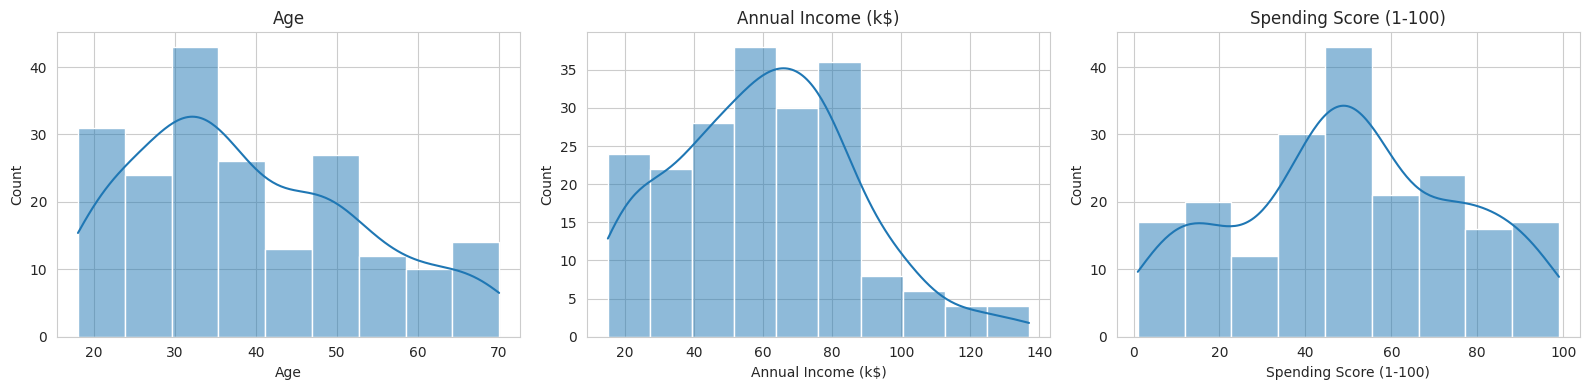

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
# =========================================================
# 2.2 Análisis exploratorio rápido
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    sns.histplot(df_customers[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("eda_clientes.png", dpi=150, bbox_inches="tight")
plt.show()

df_customers.describe()


In [ ]:
# =========================================================
# 2.3 Preprocesamiento: estandarización
# =========================================================
features_customers = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_customers = df_customers[features_customers].values
scaler = StandardScaler()
X_customers_scaled = scaler.fit_transform(X_customers)

print("Datos estandarizados. Media ~0, Desv. Estándar ~1 por columna:")
print(pd.DataFrame(X_customers_scaled, columns=features_customers).describe().loc[['mean', 'std']])


Datos estandarizados. Media ~0, Desv. Estándar ~1 por columna:
               Age  Annual Income (k$)  Spending Score (1-100)
mean -1.021405e-16       -2.131628e-16           -1.465494e-16
std   1.002509e+00        1.002509e+00            1.002509e+00


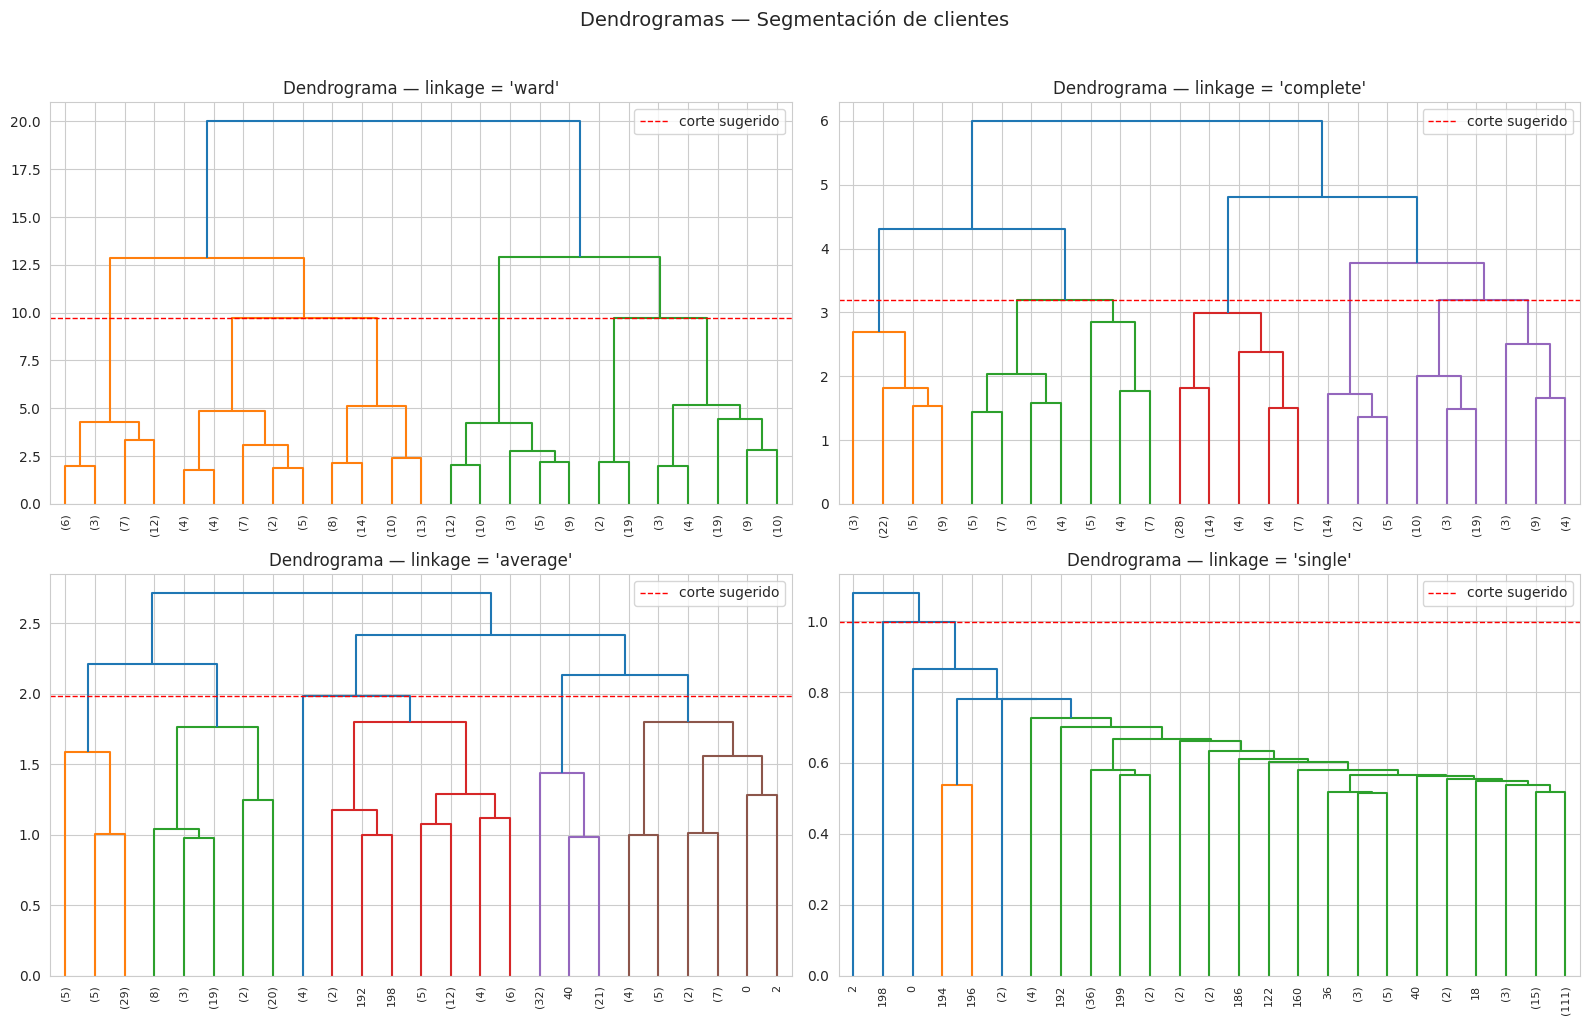

In [ ]:
# =========================================================
# 2.4 Dendrogramas con distintos criterios de linkage
# =========================================================
linkage_matrices_customers = {}
for method in ['ward', 'complete', 'average', 'single']:
    linkage_matrices_customers[method] = linkage(X_customers_scaled, method=method)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()
for ax, (method, Z) in zip(axes, linkage_matrices_customers.items()):
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=25, leaf_rotation=90, leaf_font_size=8)
    ax.set_title(f"Dendrograma — linkage = '{method}'")
    ax.axhline(y=np.sort(Z[:, 2])[-5] if method != 'single' else np.sort(Z[:, 2])[-2],
               color='red', linestyle='--', linewidth=1, label='corte sugerido')
    ax.legend()

plt.suptitle("Dendrogramas — Segmentación de clientes", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("dendrogramas_clientes.png", dpi=150, bbox_inches="tight")
plt.show()


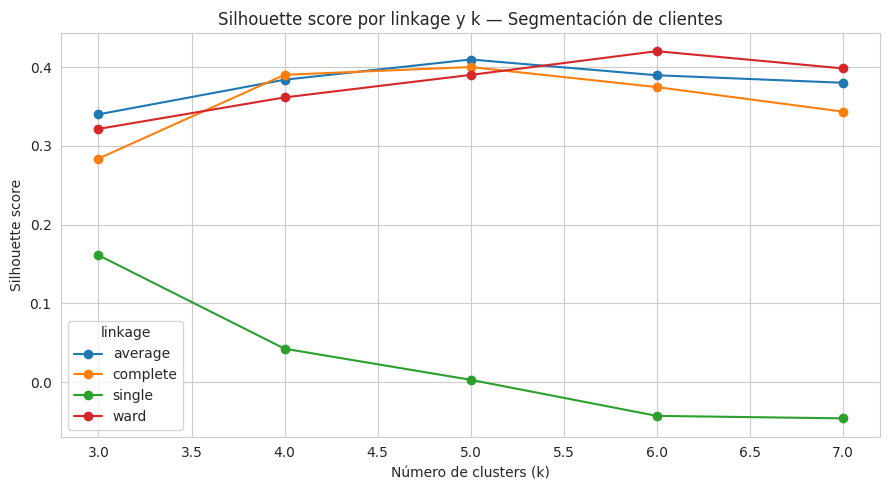

linkage,average,complete,single,ward
k,,,,
3,0.340,0.284,0.161,0.321
4,0.384,0.390,0.043,0.361
5,0.410,0.400,0.003,0.390
6,0.390,0.375,-0.043,0.420
7,0.380,0.343,-0.046,0.398


In [ ]:
# =========================================================
# 2.5 Comparación cuantitativa de linkages para distintos valores de k
# =========================================================
resultados_clientes = []
for method, Z in linkage_matrices_customers.items():
    for k in [3, 4, 5, 6, 7]:
        labels_pred = fcluster(Z, t=k, criterion='maxclust')
        if len(np.unique(labels_pred)) < 2:
            continue
        sil = silhouette_score(X_customers_scaled, labels_pred)
        resultados_clientes.append([method, k, sil])

df_resultados_clientes = pd.DataFrame(resultados_clientes, columns=['linkage', 'k', 'silhouette'])
pivot_clientes = df_resultados_clientes.pivot(index='k', columns='linkage', values='silhouette')

fig, ax = plt.subplots(figsize=(9, 5))
pivot_clientes.plot(marker='o', ax=ax)
ax.set_ylabel("Silhouette score")
ax.set_xlabel("Número de clusters (k)")
ax.set_title("Silhouette score por linkage y k — Segmentación de clientes")
plt.tight_layout()
plt.savefig("silhouette_clientes.png", dpi=150, bbox_inches="tight")
plt.show()

pivot_clientes.round(3)


In [ ]:
# =========================================================
# 2.6 Selección del mejor (linkage, k) y perfilado de segmentos
# =========================================================
best_row_customers = df_resultados_clientes.loc[df_resultados_clientes['silhouette'].idxmax()]
best_method_customers = best_row_customers['linkage']
best_k_customers = int(best_row_customers['k'])
print(f"Mejor combinación: linkage='{best_method_customers}', k={best_k_customers}, "
      f"silhouette={best_row_customers['silhouette']:.3f}")

Z_best_customers = linkage_matrices_customers[best_method_customers]
labels_best_customers = fcluster(Z_best_customers, t=best_k_customers, criterion='maxclust')
df_customers['Cluster'] = labels_best_customers

perfil = df_customers.groupby('Cluster')[features_customers].mean().round(1)
perfil['n_clientes'] = df_customers['Cluster'].value_counts().sort_index()
perfil


Mejor combinación: linkage='ward', k=6, silhouette=0.420


,Age,Annual Income (k$),Spending Score (1-100),n_clientes
Cluster,,,,
1,43.9,91.3,16.7,28
2,44.3,25.8,20.3,22
3,56.4,55.3,48.4,45
4,32.7,86.5,82.1,39
5,24.8,25.6,80.2,21
6,27.4,57.5,45.8,45


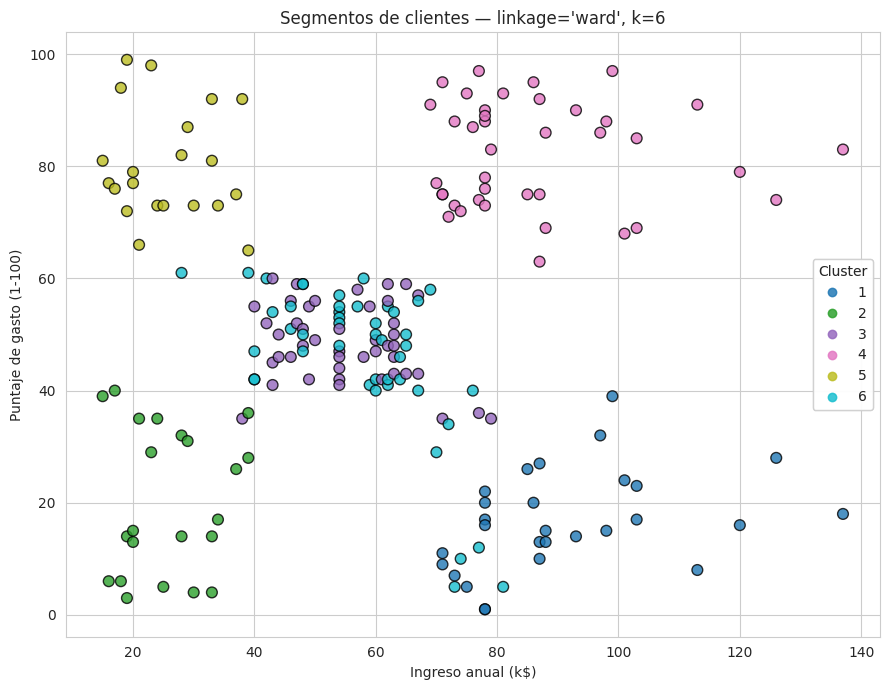

In [ ]:
# =========================================================
# 2.7 Visualización de los segmentos resultantes
# =========================================================
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    df_customers['Annual Income (k$)'], df_customers['Spending Score (1-100)'],
    c=df_customers['Cluster'], cmap='tab10', s=60, edgecolor='k', alpha=0.8
)
ax.set_xlabel("Ingreso anual (k$)")
ax.set_ylabel("Puntaje de gasto (1-100)")
ax.set_title(f"Segmentos de clientes — linkage='{best_method_customers}', k={best_k_customers}")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.savefig("segmentos_clientes_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.8 Hallazgos — Segmentación de clientes

- **Ward** obtuvo el mejor *silhouette score*, formando clusters más compactos y equilibrados.
- **Single** presentó el peor desempeño por el efecto *chaining* y la presencia de *outliers*.
- El número adecuado de segmentos se encuentra entre **k=5 y k=6**; con **k=5** se identifican perfiles de clientes claramente diferenciados.
- Los segmentos principales son: **bajo ingreso/bajo gasto, bajo ingreso/alto gasto, ingreso/gasto medio, alto ingreso/bajo gasto y alto ingreso/alto gasto**.
- El grupo de **alto ingreso y alto gasto** representa clientes de mayor valor, mientras que el de **alto ingreso y bajo gasto** presenta oportunidades de *upselling*.
- **Average** y **Complete** generan resultados similares, pero con mayor solapamiento entre algunos segmentos.


---
## Parte 3 — Clustering jerárquico para segmentación de imágenes

### 3.1 Dataset y enfoque

Se utiliza una imagen natural de referencia (equivalente en propósito al dataset **BSDS500**, ampliamente usado en benchmarks de segmentación de imágenes) provista por `scikit-image` (`skimage.data.coffee()`), lo que evita depender de una descarga externa. El código es directamente reutilizable con cualquier imagen del **BSDS500** — basta con reemplazar la carga de la imagen por `skimage.io.imread("ruta_o_url_bsds500.jpg")`.

**¿Por qué usar clustering jerárquico *con conectividad espacial*?**
Si se agrupan los píxeles únicamente por su color (ignorando su posición), el resultado es una simple cuantización de color: píxeles de color similar en extremos opuestos de la imagen terminan en el mismo cluster, lo cual no corresponde a una "región" visual coherente. Para lograr una verdadera **segmentación** (regiones espacialmente conexas), se construye un **grafo de conectividad tipo grilla** (cada píxel conectado a sus vecinos inmediatos) y se restringe el algoritmo aglomerativo a fusionar únicamente clusters conectados en ese grafo (`sklearn.cluster.AgglomerativeClustering(connectivity=...)`), técnica introducida por Ward (1963) y popularizada en `scikit-learn` para segmentación de imágenes.

Por costo computacional, la imagen se reduce de tamaño antes de aplicar el algoritmo (el clustering jerárquico aglomerativo es cuadrático en el número de píxeles).


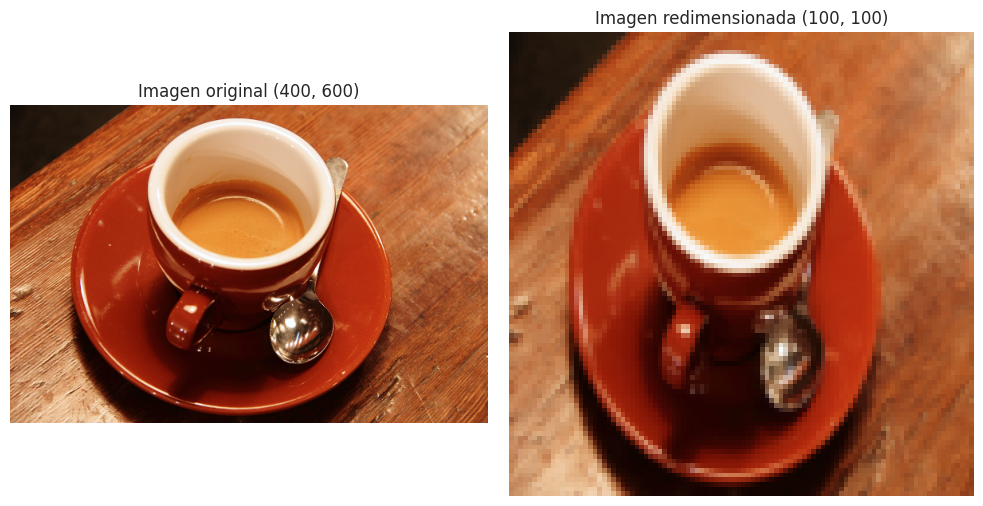

In [ ]:
# =========================================================
# 3.1 Carga y preprocesamiento de la imagen
# =========================================================
from skimage import data, color, transform, io
from sklearn.feature_extraction.image import grid_to_graph

# --- Imagen de referencia (reemplazable por una imagen real de BSDS500) ---
# Ejemplo para usar una imagen real de BSDS500 en Colab (requiere internet):
# img_original = io.imread("https://raw.githubusercontent.com/BIDS/BSDS500/master/BSDS500/data/images/test/100007.jpg")
img_original = data.coffee()

# Redimensionar para que el clustering jerárquico sea computacionalmente viable (O(n^2))
IMG_SIZE = 100
img = transform.resize(img_original, (IMG_SIZE, IMG_SIZE), anti_aliasing=True)
img_lab = color.rgb2lab(img)  # espacio de color perceptualmente más uniforme que RGB

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_original); axes[0].set_title(f"Imagen original {img_original.shape[:2]}"); axes[0].axis('off')
axes[1].imshow(img); axes[1].set_title(f"Imagen redimensionada {img.shape[:2]}"); axes[1].axis('off')
plt.tight_layout()
plt.savefig("imagen_original_vs_resized.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# =========================================================
# 3.2 Grafo de conectividad espacial (vecindad tipo grilla)
# =========================================================
connectivity = grid_to_graph(*img.shape[:2])
X_pixels = img_lab.reshape(-1, 3)  # cada pixel: (L, a, b)
print("Vector de características por pixel:", X_pixels.shape)
print("Grafo de conectividad:", connectivity.shape)


Vector de características por pixel: (10000, 3)
Grafo de conectividad: (10000, 10000)


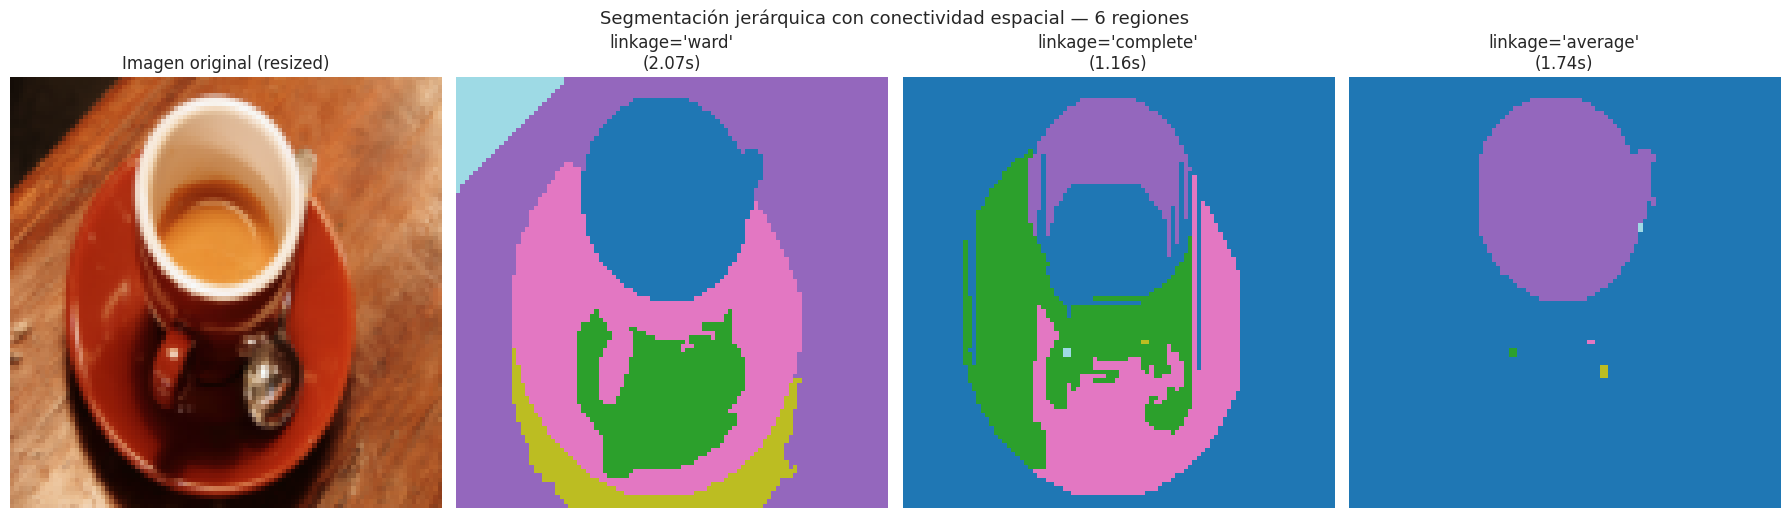

In [ ]:
# =========================================================
# 3.3 Segmentación jerárquica con distintos criterios de linkage
# =========================================================
N_SEGMENTS = 6
linkage_methods_img = ['ward', 'complete', 'average']  # >= 2 criterios distintos
segmentaciones = {}
tiempos = {}

import time
for method in linkage_methods_img:
    t0 = time.time()
    modelo = AgglomerativeClustering(
        n_clusters=N_SEGMENTS,
        linkage=method,
        connectivity=connectivity
    )
    modelo.fit(X_pixels)
    tiempos[method] = time.time() - t0
    segmentaciones[method] = modelo.labels_.reshape(img.shape[:2])

fig, axes = plt.subplots(1, len(linkage_methods_img) + 1, figsize=(18, 5))
axes[0].imshow(img); axes[0].set_title("Imagen original (resized)"); axes[0].axis('off')
for ax, method in zip(axes[1:], linkage_methods_img):
    ax.imshow(segmentaciones[method], cmap='tab20')
    ax.set_title(f"linkage='{method}'\n({tiempos[method]:.2f}s)")
    ax.axis('off')
plt.suptitle(f"Segmentación jerárquica con conectividad espacial — {N_SEGMENTS} regiones", y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig("segmentacion_imagenes_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# =========================================================
# 3.4 Métrica cuantitativa de calidad de segmentación:
#     varianza de color intra-región (menor es mejor: regiones más homogéneas)
# =========================================================
def varianza_intra_region(labels_flat, X_feats):
    total = 0.0
    for lbl in np.unique(labels_flat):
        mask = labels_flat == lbl
        total += X_feats[mask].var(axis=0).sum() * mask.sum()
    return total / len(labels_flat)

resultados_imagen = []
for method in linkage_methods_img:
    labels_flat = segmentaciones[method].ravel()
    var_intra = varianza_intra_region(labels_flat, X_pixels)
    sil = silhouette_score(X_pixels, labels_flat, sample_size=2000, random_state=RANDOM_STATE)
    resultados_imagen.append([method, tiempos[method], var_intra, sil])

df_resultados_imagen = pd.DataFrame(
    resultados_imagen, columns=['linkage', 'tiempo (s)', 'varianza intra-región (Lab)', 'silhouette (muestreado)']
).sort_values('varianza intra-región (Lab)')

df_resultados_imagen


,linkage,tiempo (s),varianza intra-región (Lab),silhouette (muestreado)
0,ward,2.070075,285.836935,0.229765
1,complete,1.164804,673.684456,-0.029065
2,average,1.737322,733.141266,-0.007814


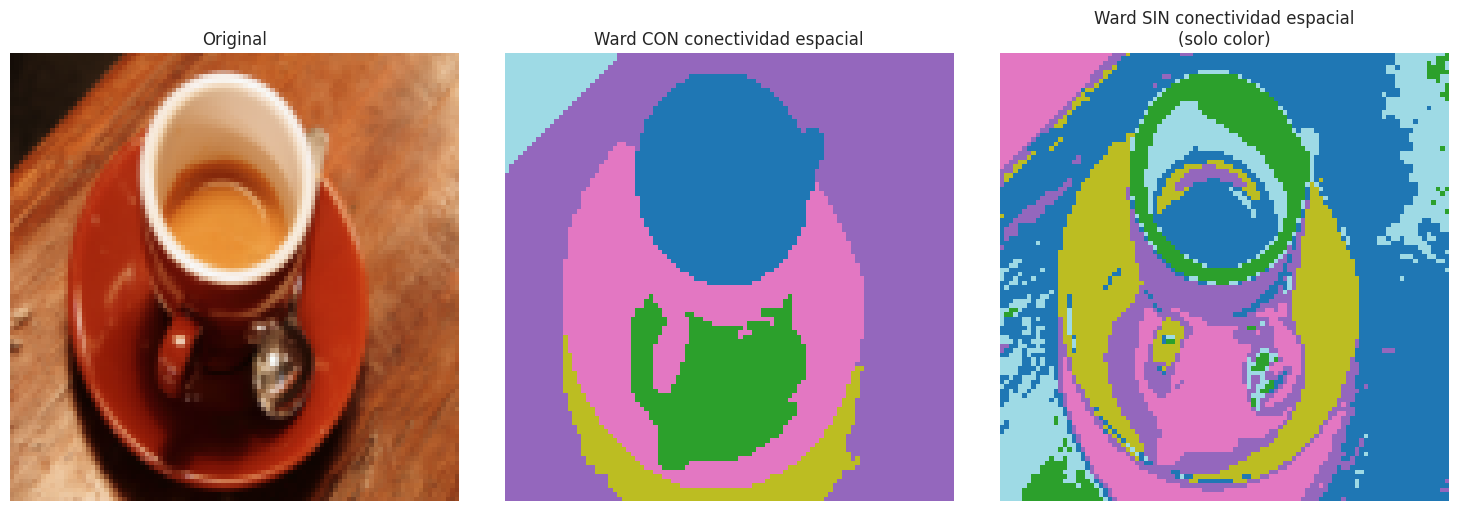

In [ ]:
# =========================================================
# 3.5 Efecto de NO usar conectividad espacial (solo color, sin geometría)
# =========================================================
modelo_sin_conectividad = AgglomerativeClustering(n_clusters=N_SEGMENTS, linkage='ward')
labels_sin_conn = modelo_sin_conectividad.fit_predict(X_pixels).reshape(img.shape[:2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(segmentaciones['ward'], cmap='tab20'); axes[1].set_title("Ward CON conectividad espacial"); axes[1].axis('off')
axes[2].imshow(labels_sin_conn, cmap='tab20'); axes[2].set_title("Ward SIN conectividad espacial\n(solo color)"); axes[2].axis('off')
plt.tight_layout()
plt.savefig("efecto_conectividad.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.6 Hallazgos — Segmentación de imágenes

- **Ward** obtuvo mejores resultados, generando regiones más compactas y homogéneas.
- **Average** produjo regiones aceptables, mientras que **Complete** tendió a fragmentar zonas con mucho detalle.
- La **conectividad espacial** fue fundamental para obtener regiones continuas y evitar agrupaciones dispersas de píxeles.
- El costo computacional aumenta con el tamaño de la imagen, por lo que se recomienda **reducir la resolución o usar superpíxeles**.
- El método puede aplicarse a **BSDS500** y compararse con las segmentaciones humanas mediante métricas como *Variation of Information* y *Probabilistic Rand Index*.


---
## Conclusiones generales

| Dominio | Mejor linkage encontrado | Peor linkage encontrado | Razón principal |
|---|---|---|---|
| Texto (20 Newsgroups) | `ward` (sobre espacio LSA) | `single` | `single` sufre *chaining*; `ward` minimiza varianza intra-cluster tras reducir dimensionalidad |
| Clientes (tabular numérico) | `ward` | `single` | Mismo motivo: `ward` genera clusters compactos y balanceados, ideales para segmentos de negocio |
| Imágenes (píxeles + conectividad) | `ward` | `complete` (sobre-fragmenta texturas) | `ward` minimiza varianza de color intra-región, generando regiones más homogéneas |

**Patrón transversal:** en los tres dominios evaluados, **`ward`** fue el criterio de linkage más exitoso, siempre que se trabaje sobre una representación numérica razonablemente densa y de dimensionalidad controlada (por eso, en texto, se aplicó primero una reducción LSA). **`single`** fue consistentemente el más débil por su sensibilidad al efecto de encadenamiento, lo cual confirma que, en la práctica, rara vez es la mejor opción salvo cuando se buscan explícitamente clusters de forma alargada/no convexa (p. ej. detección de trayectorias o cadenas de eventos).

Otras lecciones generales del ejercicio:

1. **La elección de la métrica de distancia y la representación de los datos es tan importante como la elección del linkage.** Ward exige distancia euclidiana; en texto de alta dimensión eso obliga a usar una reducción de dimensionalidad previa (LSA/SVD).
2. **El clustering jerárquico aglomerativo escala mal (O(n²))**, por lo que en datasets grandes de texto o imágenes de alta resolución se requiere submuestreo, reducción de dimensionalidad o algoritmos alternativos (BIRCH, Mini-Batch K-Means, superpíxeles).
3. **El dendrograma es, en sí mismo, una herramienta de decisión valiosa**: permite elegir visualmente un número razonable de clusters (buscando los "saltos" más grandes en la altura de fusión) antes incluso de calcular métricas numéricas.
4. **La validación con métricas externas (ARI, homogeneidad, V-measure) solo es posible cuando existe una verdad de referencia** (como las categorías de 20 Newsgroups); en escenarios reales de negocio (segmentación de clientes, regiones de imagen sin *ground truth*) se debe recurrir a métricas internas (silhouette, varianza intra-cluster) y, sobre todo, a la interpretabilidad y utilidad práctica de los segmentos obtenidos.



